In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('final_alcohol_analysis.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nBasic statistics:")
print(df[['Total_PerCapita', 'BAC_0.08+_Deaths_PerCapita']].describe())

Dataset shape: (51, 29)

First few rows:
        State  Beer_Volume  Beer_Ethanol  Beer_PerCapita  Wine_Volume  \
0     Alabama        89404          4023            0.95         7766   
1      Alaska        13174           593            0.99         2428   
2     Arizona       140926          6342            1.03        18311   
3    Arkansas        51419          2314            0.92         4458   
4  California       797599         35892            1.10       156026   

   Wine_Ethanol  Wine_PerCapita  Spirits_Volume  Spirits_Ethanol  \
0          1002            0.24            8355             3434   
1           313            0.53            1871              769   
2          2362            0.38           14869             6111   
3           575            0.23            4812             1978   
4         20127            0.62           92196            37893   

   Spirits_PerCapita  ...  BAC_0.01+_Number  BAC_0.01+_Percent  Total_Number  \
0               0.81  ...      

In [5]:
# Calculate correlation between alcohol consumption and drunk driving deaths
correlation = df['Total_PerCapita'].corr(df['BAC_0.08+_Deaths_PerCapita'])
print(f"Correlation between alcohol consumption and drunk driving deaths: {correlation:.4f}")

# Linear regression
x = df['Total_PerCapita']
y = df['BAC_0.08+_Deaths_PerCapita']

# Calculate slope and intercept
x_mean = x.mean()
y_mean = y.mean()
slope = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
intercept = y_mean - slope * x_mean

# Calculate R-squared
y_pred = slope * x + intercept
ss_res = ((y - y_pred) ** 2).sum()
ss_tot = ((y - y_mean) ** 2).sum()
r_squared = 1 - (ss_res / ss_tot)

print(f"R-squared: {r_squared:.4f}")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

Correlation between alcohol consumption and drunk driving deaths: -0.0539
R-squared: 0.0029
Slope: -0.1325
Intercept: 4.4612


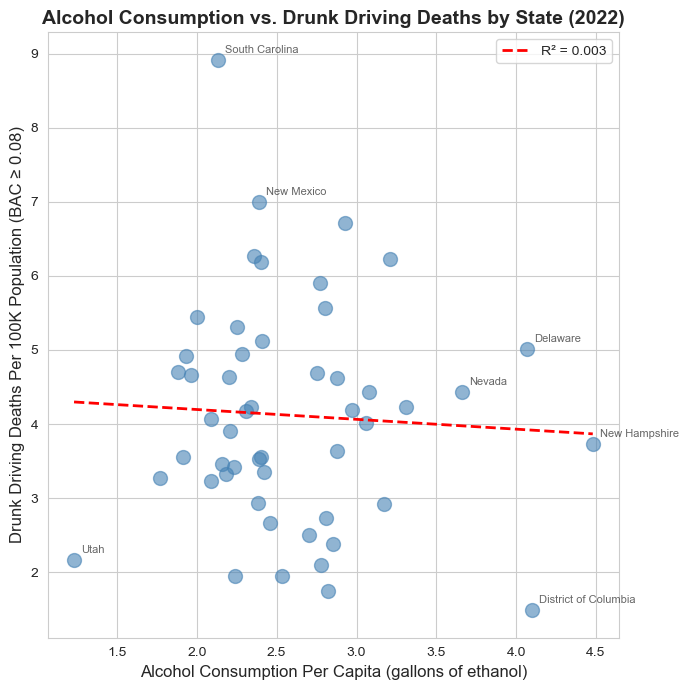

In [6]:
plt.figure(figsize=(7, 7))
plt.scatter(df['Total_PerCapita'], df['BAC_0.08+_Deaths_PerCapita'], 
            alpha=0.6, s=100, color='steelblue')

# Add regression line
x_line = np.linspace(df['Total_PerCapita'].min(), df['Total_PerCapita'].max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, 'r--', linewidth=2, 
         label=f'R² = {r_squared:.3f}')

# Label some interesting states
for idx, row in df.iterrows():
    # Label states with highest/lowest consumption or deaths
    if (row['Total_PerCapita'] > 3.5 or row['Total_PerCapita'] < 1.5 or 
        row['BAC_0.08+_Deaths_PerCapita'] > 7):
        plt.annotate(row['State'], 
                    xy=(row['Total_PerCapita'], row['BAC_0.08+_Deaths_PerCapita']),
                    xytext=(5, 5), textcoords='offset points', 
                    fontsize=8, alpha=0.7)

plt.xlabel('Alcohol Consumption Per Capita (gallons of ethanol)', fontsize=12)
plt.ylabel('Drunk Driving Deaths Per 100K Population (BAC ≥ 0.08)', fontsize=12)
plt.title('Alcohol Consumption vs. Drunk Driving Deaths by State (2022)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Compare high vs low drinking states
high_drinking = df[df['Decile'] <= 3]  # Top 30% consumption
low_drinking = df[df['Decile'] >= 8]   # Bottom 30% consumption

print(f"High drinking states avg deaths per 100k: {high_drinking['BAC_0.08+_Deaths_PerCapita'].mean():.2f}")
print(f"Low drinking states avg deaths per 100k: {low_drinking['BAC_0.08+_Deaths_PerCapita'].mean():.2f}")
print(f"Difference: {high_drinking['BAC_0.08+_Deaths_PerCapita'].mean() - low_drinking['BAC_0.08+_Deaths_PerCapita'].mean():.2f}")

High drinking states avg deaths per 100k: 3.99
Low drinking states avg deaths per 100k: 4.24
Difference: -0.26


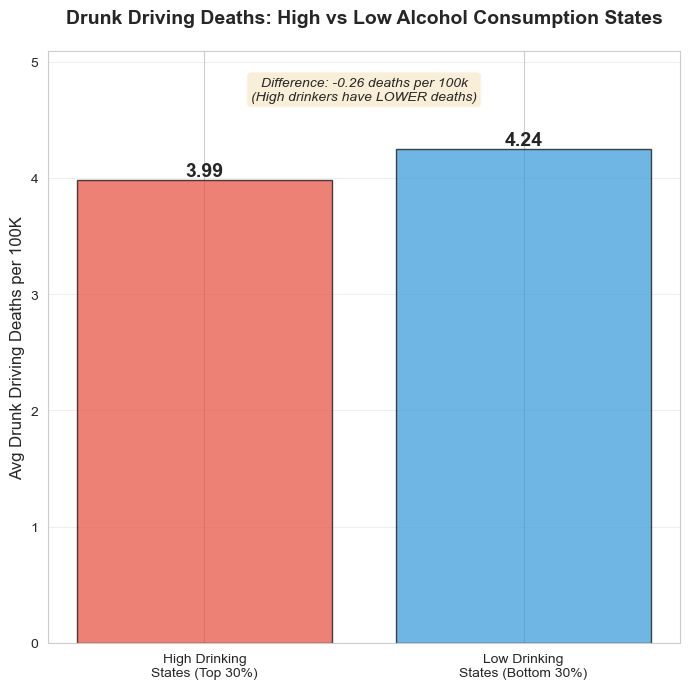

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))

categories = ['High Drinking\nStates (Top 30%)', 'Low Drinking\nStates (Bottom 30%)']
values = [
    high_drinking['BAC_0.08+_Deaths_PerCapita'].mean(),
    low_drinking['BAC_0.08+_Deaths_PerCapita'].mean()
]

bars = ax.bar(categories, values, color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')

# Value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Avg Drunk Driving Deaths per 100K', fontsize=12)
ax.set_title('Drunk Driving Deaths: High vs Low Alcohol Consumption States', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis='y', alpha=0.3)

# Annotation
difference = values[0] - values[1]
ax.text(0.5, max(values) * 1.1, 
        f'Difference: {difference:.2f} deaths per 100k\n(High drinkers have LOWER deaths)',
        ha='center', fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [14]:
print(f"Beer consumption: {df['Beer_PerCapita'].corr(df['BAC_0.08+_Deaths_PerCapita']):.4f}")
print(f"Wine consumption: {df['Wine_PerCapita'].corr(df['BAC_0.08+_Deaths_PerCapita']):.4f}")
print(f"Spirits consumption: {df['Spirits_PerCapita'].corr(df['BAC_0.08+_Deaths_PerCapita']):.4f}")

Beer consumption: 0.3300
Wine consumption: -0.3299
Spirits consumption: -0.1295


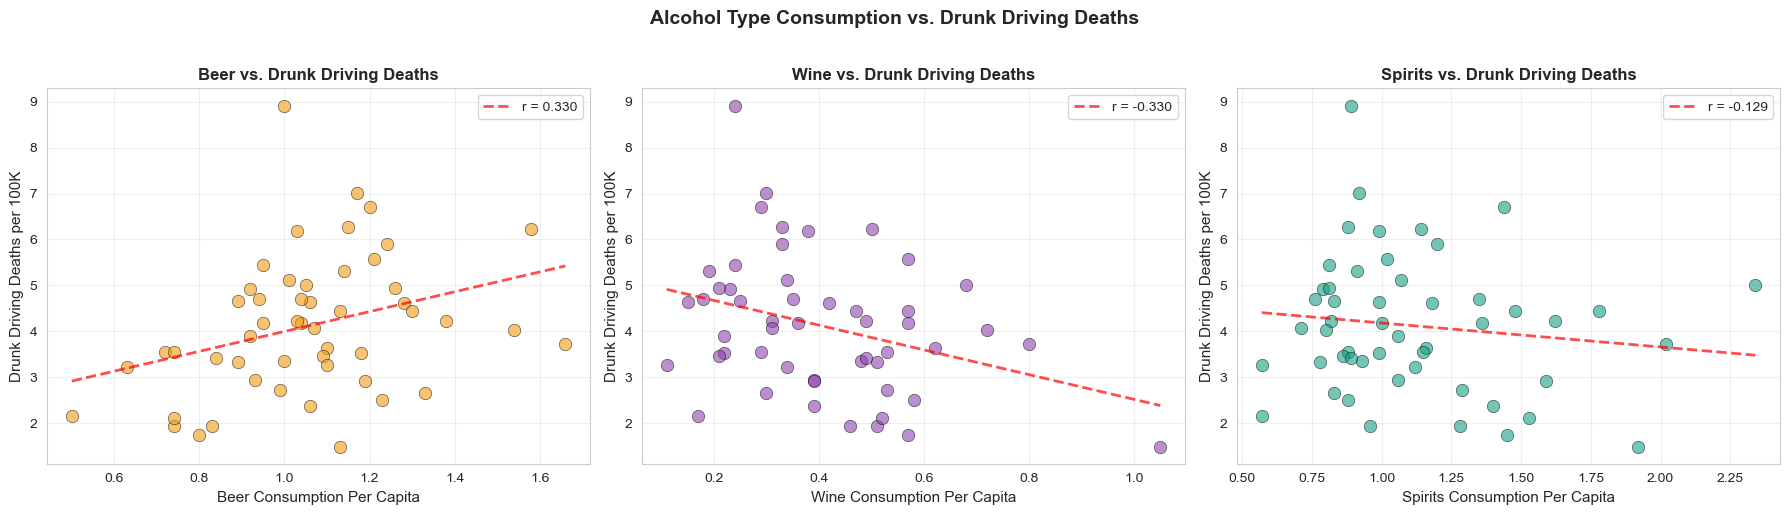

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

alcohol_types = [
    ('Beer_PerCapita', 'Beer', '#f39c12'),
    ('Wine_PerCapita', 'Wine', '#8e44ad'),
    ('Spirits_PerCapita', 'Spirits', '#16a085')
]

for ax, (col, name, color) in zip(axes, alcohol_types):
    # Scatter plot
    ax.scatter(df[col], df['BAC_0.08+_Deaths_PerCapita'], 
              alpha=0.6, s=80, color=color, edgecolor='black', linewidth=0.5)
    
    # Calculate regression line
    x_vals = df[col]
    y_vals = df['BAC_0.08+_Deaths_PerCapita']
    slope = ((x_vals - x_vals.mean()) * (y_vals - y_vals.mean())).sum() / ((x_vals - x_vals.mean()) ** 2).sum()
    intercept = y_vals.mean() - slope * x_vals.mean()
    
    # Plot regression line
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    y_line = slope * x_line + intercept
    corr = df[col].corr(df['BAC_0.08+_Deaths_PerCapita'])
    ax.plot(x_line, y_line, 'r--', linewidth=2, alpha=0.7,
           label=f'r = {corr:.3f}')
    
    ax.set_xlabel(f'{name} Consumption Per Capita', fontsize=11)
    ax.set_ylabel('Drunk Driving Deaths per 100K', fontsize=11)
    ax.set_title(f'{name} vs. Drunk Driving Deaths', fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

plt.suptitle('Alcohol Type Consumption vs. Drunk Driving Deaths', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
print("TOP 5 STATES BY DRUNK DRIVING DEATHS (per 100k)")
print(df.nlargest(5, 'BAC_0.08+_Deaths_PerCapita')[['State', 'Total_PerCapita', 'BAC_0.08+_Deaths_PerCapita']])

print("BOTTOM 5 STATES BY DRUNK DRIVING DEATHS (per 100k)")
print(df.nsmallest(5, 'BAC_0.08+_Deaths_PerCapita')[['State', 'Total_PerCapita', 'BAC_0.08+_Deaths_PerCapita']])

TOP 5 STATES BY DRUNK DRIVING DEATHS (per 100k)
             State  Total_PerCapita  BAC_0.08+_Deaths_PerCapita
40  South Carolina             2.13                    8.916007
31      New Mexico             2.39                    7.003119
50         Wyoming             2.93                    6.708166
43           Texas             2.36                    6.263826
26         Montana             3.21                    6.234042
BOTTOM 5 STATES BY DRUNK DRIVING DEATHS (per 100k)
                   State  Total_PerCapita  BAC_0.08+_Deaths_PerCapita
8   District of Columbia             4.10                    1.488532
21         Massachusetts             2.82                    1.747357
30            New Jersey             2.53                    1.943488
32              New York             2.24                    1.946420
39          Rhode Island             2.78                    2.102888


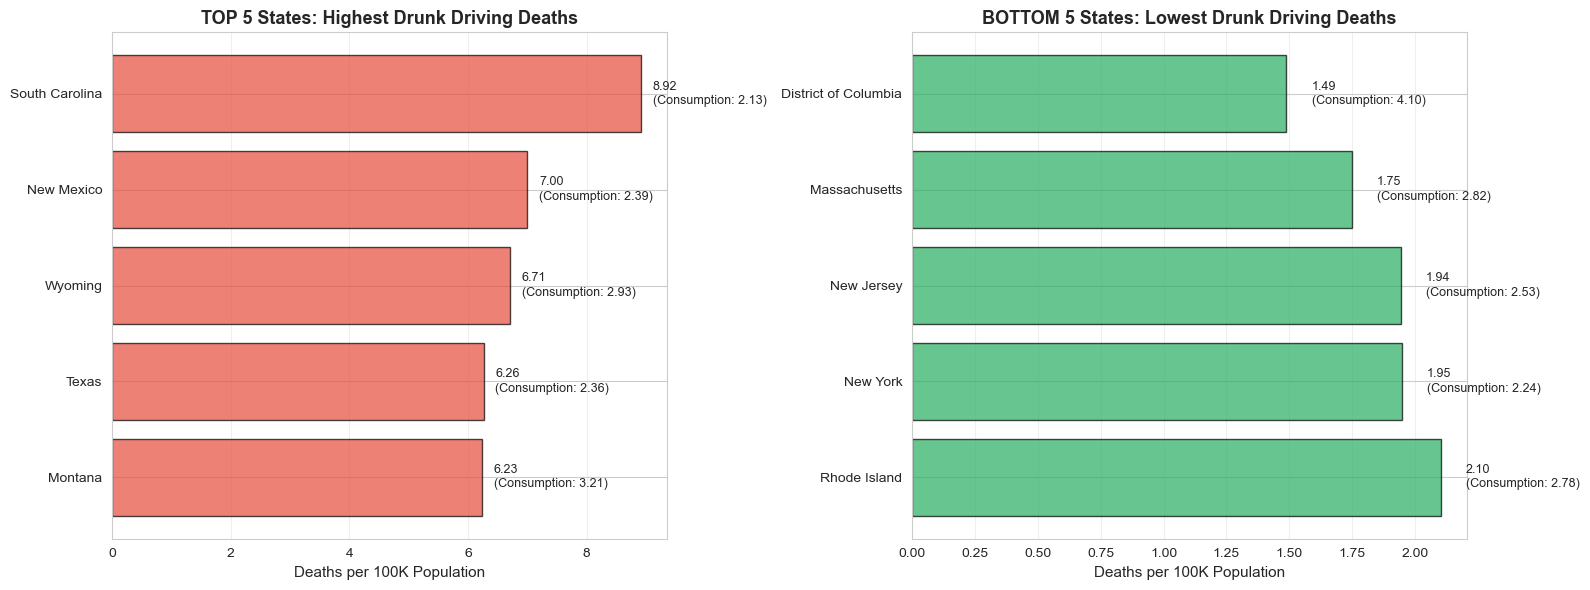

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 5 states
top5 = df.nlargest(5, 'BAC_0.08+_Deaths_PerCapita')[['State', 'Total_PerCapita', 'BAC_0.08+_Deaths_PerCapita']]
ax1.barh(range(len(top5)), top5['BAC_0.08+_Deaths_PerCapita'], color='#e74c3c', alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(top5)))
ax1.set_yticklabels(top5['State'])
ax1.invert_yaxis()
ax1.set_xlabel('Deaths per 100K Population', fontsize=11)
ax1.set_title('TOP 5 States: Highest Drunk Driving Deaths', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(top5.iterrows()):
    ax1.text(row['BAC_0.08+_Deaths_PerCapita'] + 0.2, i,
            f"{row['BAC_0.08+_Deaths_PerCapita']:.2f}\n(Consumption: {row['Total_PerCapita']:.2f})",
            va='center', fontsize=9)

# Bottom 5 states
bottom5 = df.nsmallest(5, 'BAC_0.08+_Deaths_PerCapita')[['State', 'Total_PerCapita', 'BAC_0.08+_Deaths_PerCapita']]
ax2.barh(range(len(bottom5)), bottom5['BAC_0.08+_Deaths_PerCapita'], color='#27ae60', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(bottom5)))
ax2.set_yticklabels(bottom5['State'])
ax2.invert_yaxis()
ax2.set_xlabel('Deaths per 100K Population', fontsize=11)
ax2.set_title('BOTTOM 5 States: Lowest Drunk Driving Deaths', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(bottom5.iterrows()):
    ax2.text(row['BAC_0.08+_Deaths_PerCapita'] + 0.1, i,
            f"{row['BAC_0.08+_Deaths_PerCapita']:.2f}\n(Consumption: {row['Total_PerCapita']:.2f})",
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
# FINAL TABLE :D
summary_data = {
    'Metric': [
        'Overall Correlation',
        'R-squared',
        '',
        'High Drinking States (Deaths/100k)',
        'Low Drinking States (Deaths/100k)',
        'Difference',
        '',
        'Beer Correlation',
        'Wine Correlation',
        'Spirits Correlation'
    ],
    'Value': [
        f'{correlation:.4f}',
        f'{r_squared:.4f}',
        '',
        f'{high_drinking["BAC_0.08+_Deaths_PerCapita"].mean():.2f}',
        f'{low_drinking["BAC_0.08+_Deaths_PerCapita"].mean():.2f}',
        f'{high_drinking["BAC_0.08+_Deaths_PerCapita"].mean() - low_drinking["BAC_0.08+_Deaths_PerCapita"].mean():.2f}',
        '',
        f'{df["Beer_PerCapita"].corr(df["BAC_0.08+_Deaths_PerCapita"]):.4f}',
        f'{df["Wine_PerCapita"].corr(df["BAC_0.08+_Deaths_PerCapita"]):.4f}',
        f'{df["Spirits_PerCapita"].corr(df["BAC_0.08+_Deaths_PerCapita"]):.4f}'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

                            Metric   Value
               Overall Correlation -0.0539
                         R-squared  0.0029
                                          
High Drinking States (Deaths/100k)    3.99
 Low Drinking States (Deaths/100k)    4.24
                        Difference   -0.26
                                          
                  Beer Correlation  0.3300
                  Wine Correlation -0.3299
               Spirits Correlation -0.1295
